# Kapitulli V — Vizualizimi i Rezultateve

Ky notebook lexon rezultate TASHMË TË LLOGARITURA nga `experiments/`, 
`evaluation/`, dhe `models/` — nuk rillogarit asgjë nga e para.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Ablation Study — CNN-only vs CNN+FFT vs CNN+Forensic vs Hybrid Full

In [2]:
summary_path = PROJECT_ROOT / "experiments" / "results" / "summary.json"

with open(summary_path, "r", encoding="utf-8") as f:
    experiment_results = json.load(f)

df_experiments = pd.DataFrame(experiment_results)
df_experiments = df_experiments.set_index("name")
df_experiments

,accuracy,precision,recall,f1,roc_auc
name,,,,,
cnn_fft,0.900,0.916667,0.880,0.897959,0.964720
cnn_forensic,0.899,0.916493,0.878,0.896834,0.963640
cnn_only,0.901,0.918580,0.880,0.898876,0.964232
hybrid_full,0.898,0.914583,0.878,0.895918,0.963832


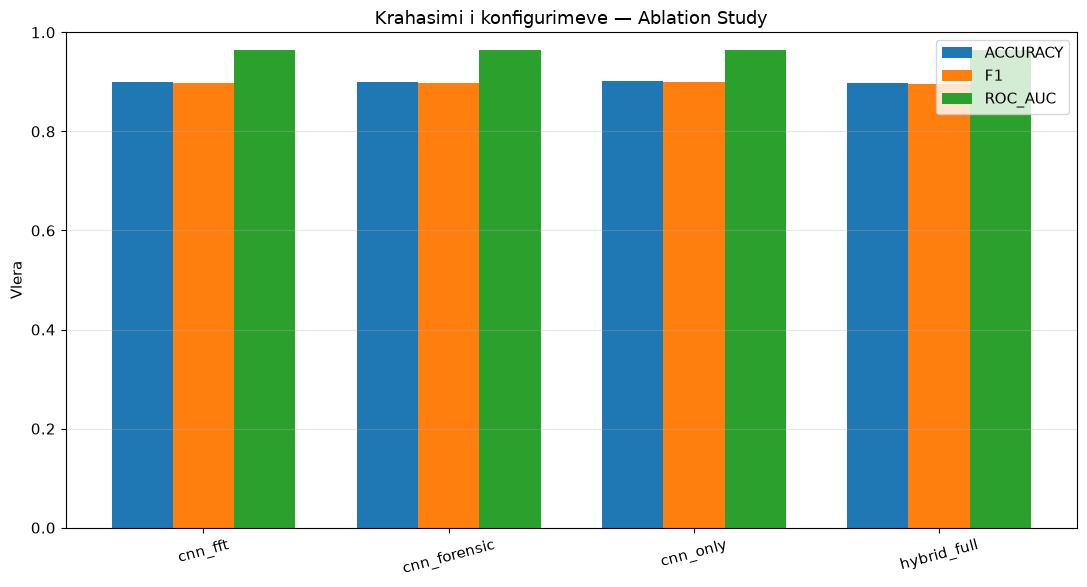

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

metrics_to_plot = ["accuracy", "f1", "roc_auc"]
x = np.arange(len(df_experiments))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, df_experiments[metric], width, label=metric.upper())

ax.set_xticks(x + width)
ax.set_xticklabels(df_experiments.index, rotation=15)
ax.set_ylabel("Vlera")
ax.set_title("Krahasimi i konfigurimeve — Ablation Study")
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "ablation_comparison.png", dpi=150)
plt.show()

## 2. Robustness ndaj Degradimit — CNN vs Fusion

In [4]:
degradation_path = PROJECT_ROOT / "evaluation" / "degradation_comparison.json"

with open(degradation_path, "r", encoding="utf-8") as f:
    degradation_results = json.load(f)

rows = []
for condition, values in degradation_results.items():
    rows.append({
        "condition": condition,
        "cnn_accuracy": values["cnn"]["accuracy"],
        "fusion_accuracy": values["fusion"]["accuracy"],
        "cnn_auc": values["cnn"]["roc_auc"],
        "fusion_auc": values["fusion"]["roc_auc"],
    })

df_degradation = pd.DataFrame(rows).set_index("condition")
df_degradation

,cnn_accuracy,fusion_accuracy,cnn_auc,fusion_auc
condition,,,,
original,0.85000,0.85000,0.930462,0.926238
jpeg_q90,0.83125,0.82750,0.921637,0.921494
jpeg_q70,0.80875,0.80500,0.903225,0.900012
jpeg_q50,0.76625,0.76875,0.858875,0.856563
resize_75,0.82000,0.81875,0.909628,0.904831
resize_25,0.61875,0.65000,0.783250,0.773256
social_media,0.78375,0.77375,0.876975,0.873138


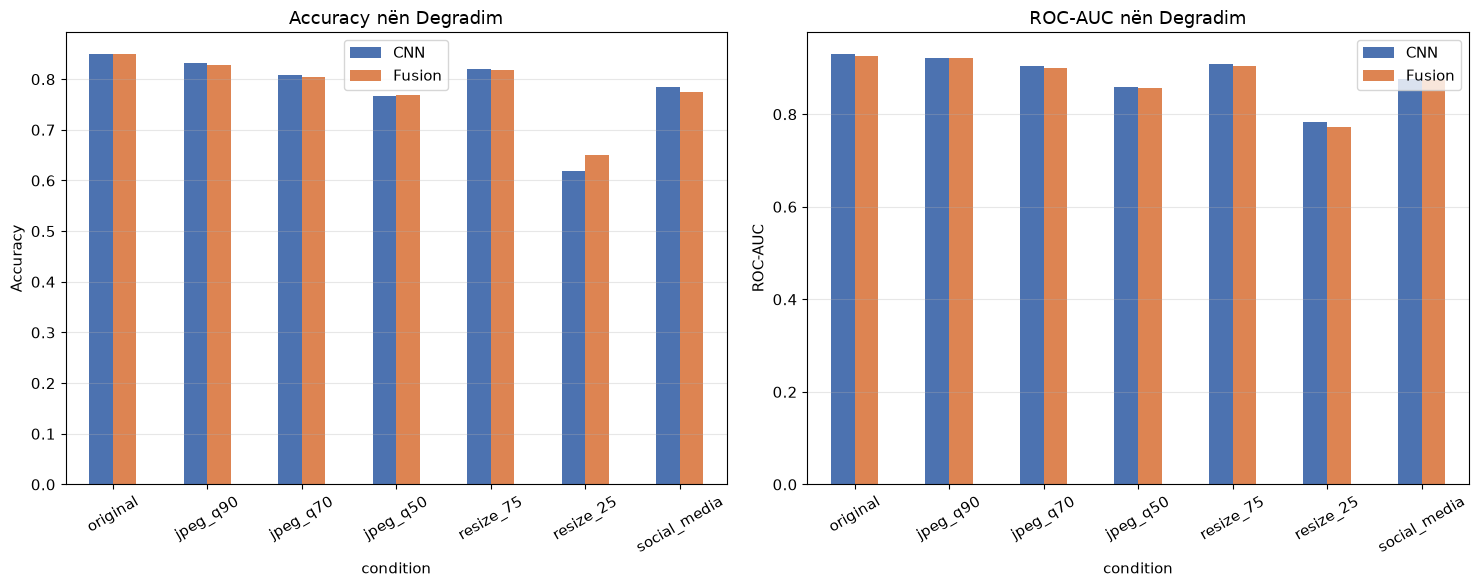

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_degradation[["cnn_accuracy", "fusion_accuracy"]].plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Accuracy nën Degradim")
axes[0].set_ylabel("Accuracy")
axes[0].legend(["CNN", "Fusion"])
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

df_degradation[["cnn_auc", "fusion_auc"]].plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"]
)
axes[1].set_title("ROC-AUC nën Degradim")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend(["CNN", "Fusion"])
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "degradation_comparison.png", dpi=150)
plt.show()

## 3. Fusion — Rezultatet Finale mbi Test Set (T1/T2 Dual-Threshold)

In [6]:
thresholds_path = PROJECT_ROOT / "models" / "fusion_thresholds.json"

with open(thresholds_path, "r", encoding="utf-8") as f:
    thresholds = json.load(f)

print(f"T1 (real, besim i lartë): {thresholds['t1_real']:.4f}")
print(f"T2 (fake, besim i lartë): {thresholds['t2_fake']:.4f}")
print(f"Target precision: {thresholds['target_precision']:.0%}")

T1 (real, besim i lartë): 0.6015
T2 (fake, besim i lartë): 0.8170
Target precision: 95%


## 4. Confusion Matrix — Fusion Final (Test Set)

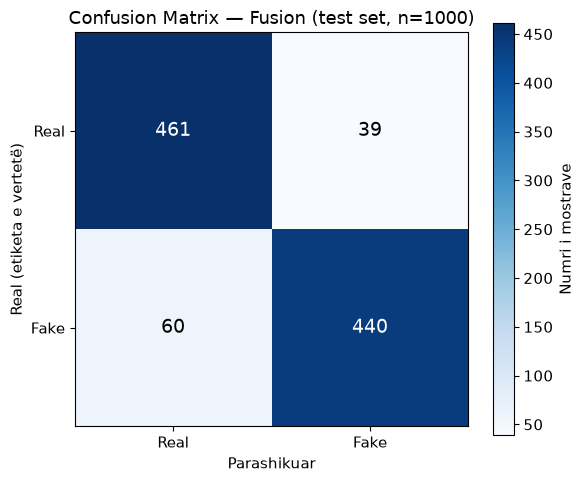

In [7]:
cm = np.array([[461, 39], [60, 440]])  # nga evaluate_fusion.py

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

labels = ["Real", "Fake"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Parashikuar"); ax.set_ylabel("Real (etiketa e vertetë)")
ax.set_title("Confusion Matrix — Fusion (test set, n=1000)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)

plt.colorbar(im, ax=ax, label="Numri i mostrave")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "fusion_confusion_matrix.png", dpi=150)
plt.show()

## 5. Gjeneralizimi Ndër-Dataset (Cross-Dataset)

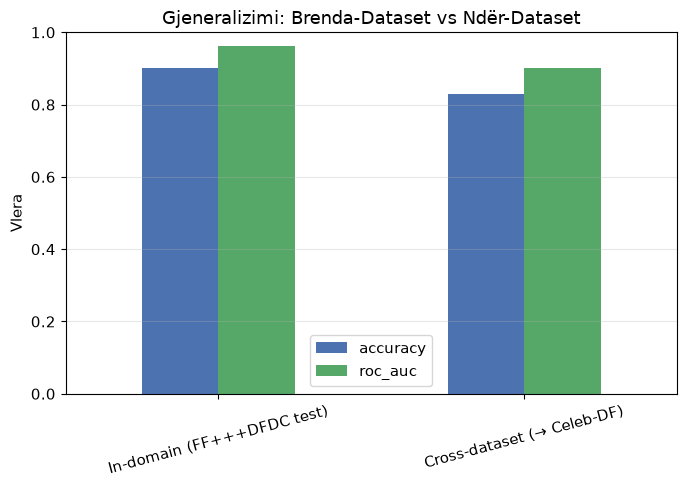

In [8]:
cross_dataset_results = {
    "In-domain (FF+++DFDC test)": {"accuracy": 0.9010, "roc_auc": 0.9617},
    "Cross-dataset (→ Celeb-DF)": {"accuracy": 0.8283, "roc_auc": 0.9021},
}

df_cross = pd.DataFrame(cross_dataset_results).T

fig, ax = plt.subplots(figsize=(7, 5))
df_cross.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_title("Gjeneralizimi: Brenda-Dataset vs Ndër-Dataset")
ax.set_ylabel("Vlera")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "cross_dataset_comparison.png", dpi=150)
plt.show()